In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df= pd.read_csv("data.csv")
df

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [5]:
df.shape

(6819, 96)

In [6]:
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [9]:
Y = df['Bankrupt?'].values
X = df.drop(df.columns[0], axis=1).values

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [11]:
data = np.hstack((X, Y.reshape(-1, 1)))

In [12]:
# Split majority/minority using Y, not entire row
majority = data[Y == 0]
minority = data[Y == 1]

In [13]:
# Upsample minority
minority_upsampled = resample(
minority,
replace=True,
n_samples=len(majority),
random_state=42)

In [14]:
# Combine
data_balanced = np.vstack((majority, minority_upsampled))
np.random.shuffle(data_balanced)

X = data_balanced[:, :-1]
Y = data_balanced[:, -1]
       

In [15]:
# Final combined
data = np.hstack((X, Y.reshape(-1, 1)))


# EDA

In [16]:
TARGET = 'Bankrupt?'
features = [c for c in df.columns if c != TARGET]

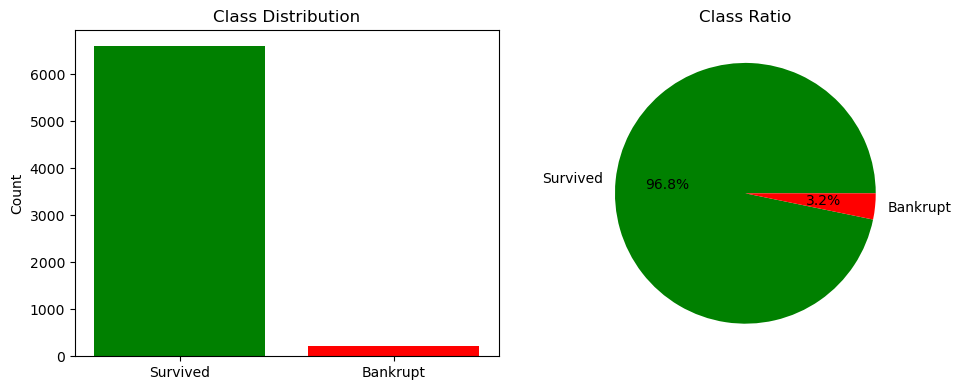

In [24]:
# Class distribution
counts = df[TARGET].value_counts()

plt.figure(figsize=(10,4))

# Bar plot
plt.subplot(1,2,1)
plt.bar(['Survived', 'Bankrupt'], counts.values, color=['green','red'])
plt.title("Class Distribution")
plt.ylabel("Count")

# Pie chart
plt.subplot(1,2,2)
plt.pie(counts.values, labels=['Survived','Bankrupt'],
        autopct='%1.1f%%', colors=['green','red'])
plt.title("Class Ratio")

plt.tight_layout()
plt.show()

In [22]:
# Top 20 features correlated with target
corr = df.corr()[TARGET].drop(TARGET)

top20 = corr.abs().nlargest(20).index
vals = corr[top20].sort_values()



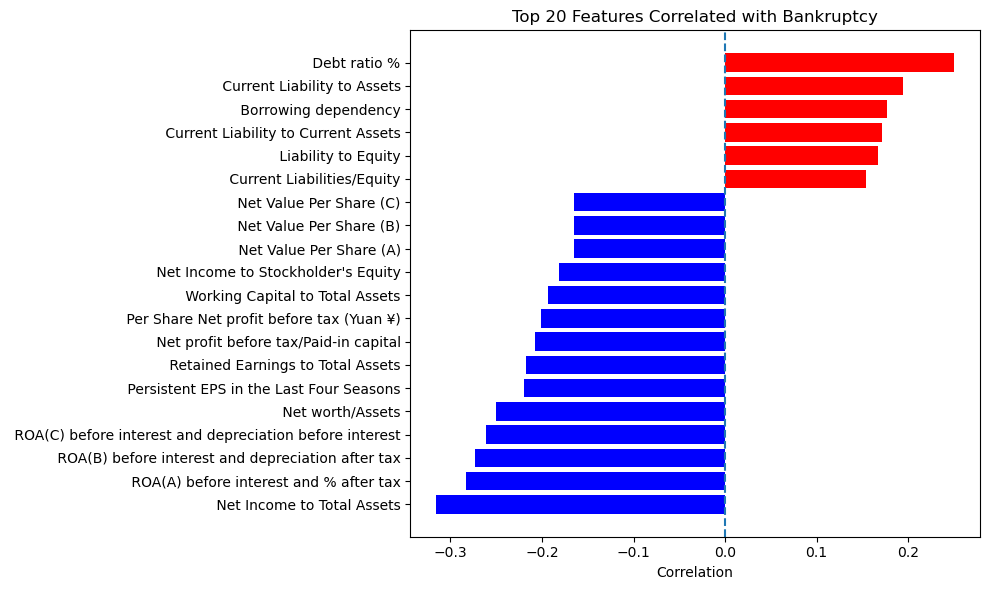

In [23]:
# Plot
plt.figure(figsize=(10,6))
colors = ['red' if v > 0 else 'blue' for v in vals]

plt.barh(vals.index, vals.values, color=colors)
plt.axvline(0, linestyle='--')

plt.title("Top 20 Features Correlated with Bankruptcy")
plt.xlabel("Correlation")

plt.tight_layout()
plt.show()

In [27]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

In [44]:
## Bankrupt vs Survived 

# Top features
top8 = [
    'Net_Income_to_Total_Assets',
    'ROA(A)_before_interest_and_%_after_tax',
    'Debt_ratio_%',
    'Persistent_EPS_in_the_Last_Four_Seasons',
    'Retained_Earnings_to_Total_Assets',
    'Net_worth/Assets',
    'Borrowing_dependency',
    'Current_Liability_to_Assets']

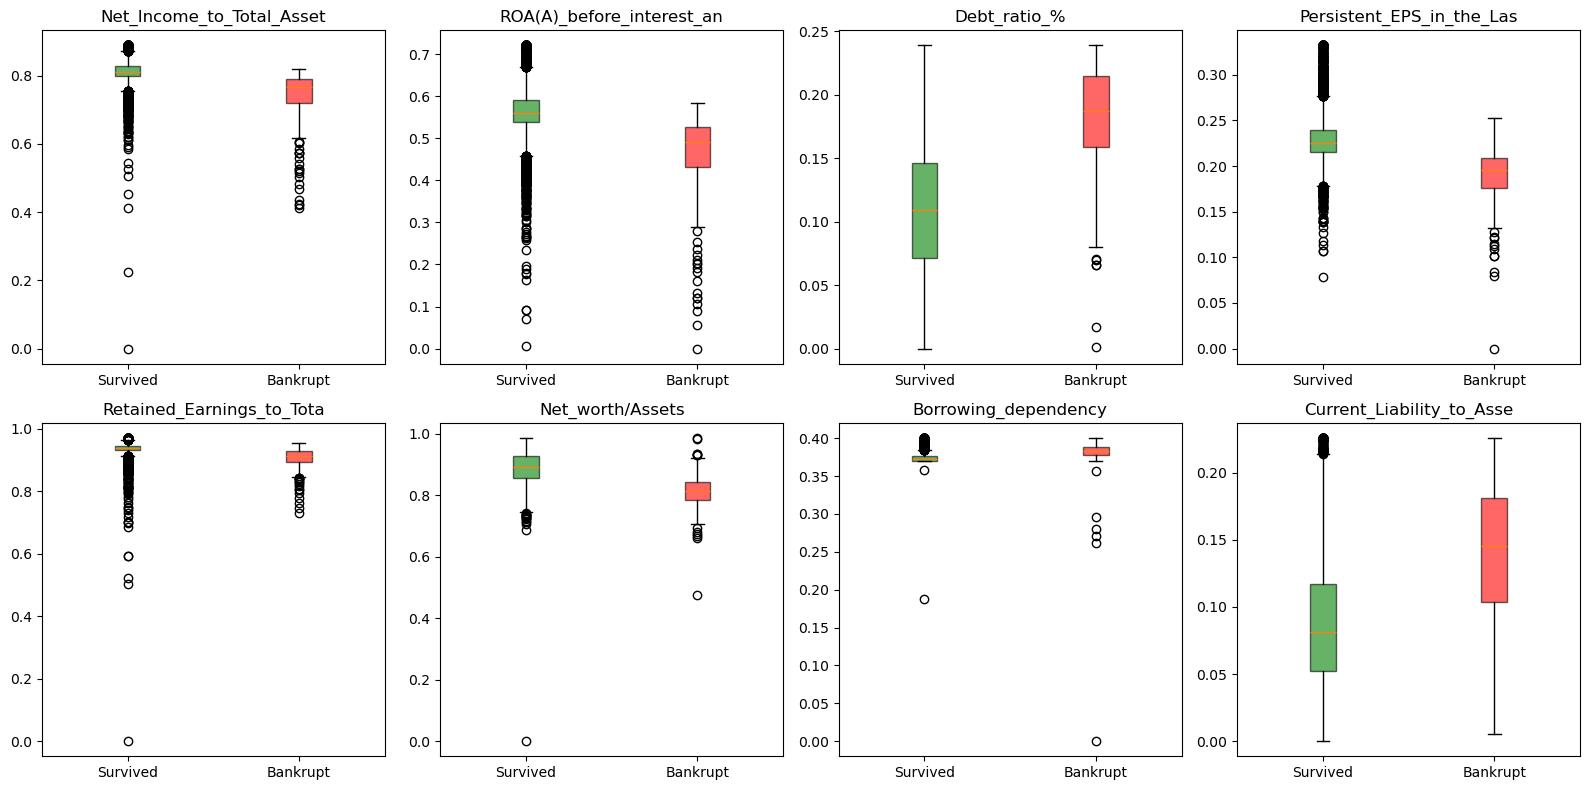

In [45]:
plt.figure(figsize=(16,8))

for i, col in enumerate(top8, 1):
    plt.subplot(2,4,i)
    # Cap extreme values
    temp = df[[col, TARGET]].copy()
    temp[col] = temp[col].clip(upper=temp[col].quantile(0.99))
    bp= plt.boxplot([temp[temp[TARGET]==0][col],
                 temp[temp[TARGET]==1][col]],
                labels=['Survived','Bankrupt'],
                patch_artist=True)
    colors = ['green', 'red']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        
    plt.title(col[:25])  # shorten title
plt.tight_layout()
plt.show()

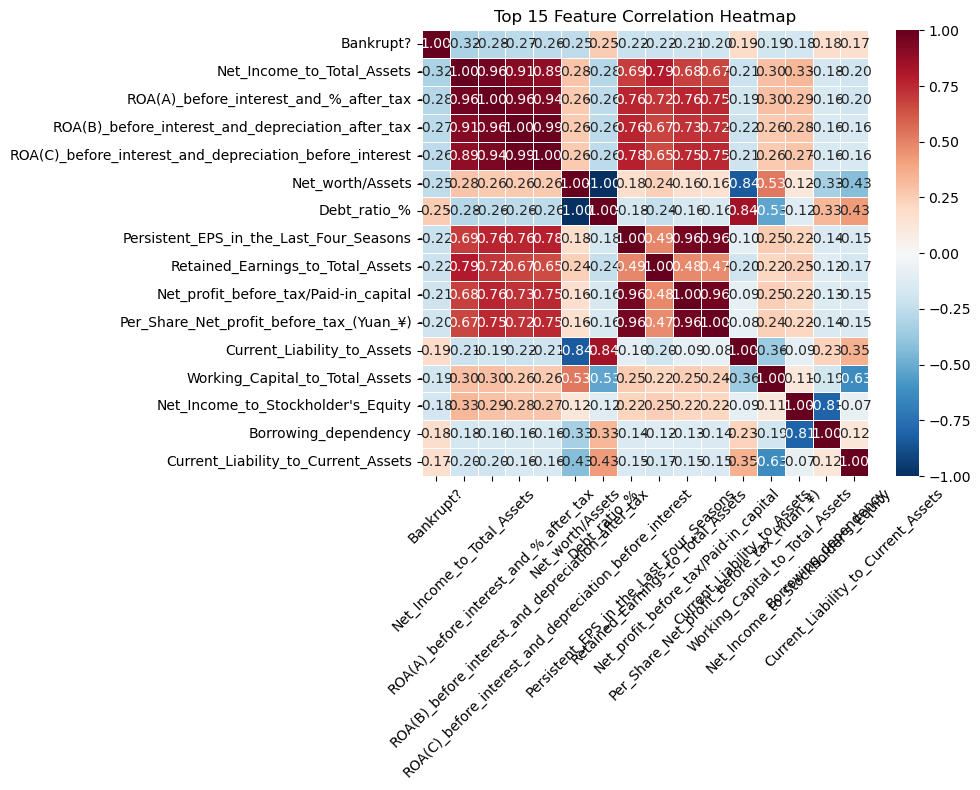

In [46]:
# Top 15 correlated features
top15 = df.corr()[TARGET].abs().nlargest(16).index  # includes target

corr_matrix = df[top15].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    annot=True,
    fmt='.2f',
    linewidths=0.5)
plt.title("Top 15 Feature Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Preprocessing Pipeline

In [47]:
# Clean all column names
df.columns = df.columns.str.strip()

In [48]:
print(df.columns.tolist())

['Bankrupt?', 'ROA(C)_before_interest_and_depreciation_before_interest', 'ROA(A)_before_interest_and_%_after_tax', 'ROA(B)_before_interest_and_depreciation_after_tax', 'Operating_Gross_Margin', 'Realized_Sales_Gross_Margin', 'Operating_Profit_Rate', 'Pre-tax_net_Interest_Rate', 'After-tax_net_Interest_Rate', 'Non-industry_income_and_expenditure/revenue', 'Continuous_interest_rate_(after_tax)', 'Operating_Expense_Rate', 'Research_and_development_expense_rate', 'Cash_flow_rate', 'Interest-bearing_debt_interest_rate', 'Tax_rate_(A)', 'Net_Value_Per_Share_(B)', 'Net_Value_Per_Share_(A)', 'Net_Value_Per_Share_(C)', 'Persistent_EPS_in_the_Last_Four_Seasons', 'Cash_Flow_Per_Share', 'Revenue_Per_Share_(Yuan_¥)', 'Operating_Profit_Per_Share_(Yuan_¥)', 'Per_Share_Net_profit_before_tax_(Yuan_¥)', 'Realized_Sales_Gross_Profit_Growth_Rate', 'Operating_Profit_Growth_Rate', 'After-tax_Net_Profit_Growth_Rate', 'Regular_Net_Profit_Growth_Rate', 'Continuous_Net_Profit_Growth_Rate', 'Total_Asset_Growth_R

In [52]:
[col for col in df.columns if 'ROA' in col]

['ROA(C)_before_interest_and_depreciation_before_interest',
 'ROA(A)_before_interest_and_%_after_tax',
 'ROA(B)_before_interest_and_depreciation_after_tax']

In [50]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [54]:
print('ROA(C)_before_interest_and_depreciation_before_interest' in df.columns)

True


In [55]:
for col in features:
    if col not in df.columns:
        print("Wrong column:", col)

Wrong column:  ROA(C) before interest and depreciation before interest
Wrong column:  ROA(A) before interest and % after tax
Wrong column:  ROA(B) before interest and depreciation after tax
Wrong column:  Operating Gross Margin
Wrong column:  Realized Sales Gross Margin
Wrong column:  Operating Profit Rate
Wrong column:  Pre-tax net Interest Rate
Wrong column:  After-tax net Interest Rate
Wrong column:  Non-industry income and expenditure/revenue
Wrong column:  Continuous interest rate (after tax)
Wrong column:  Operating Expense Rate
Wrong column:  Research and development expense rate
Wrong column:  Cash flow rate
Wrong column:  Interest-bearing debt interest rate
Wrong column:  Tax rate (A)
Wrong column:  Net Value Per Share (B)
Wrong column:  Net Value Per Share (A)
Wrong column:  Net Value Per Share (C)
Wrong column:  Persistent EPS in the Last Four Seasons
Wrong column:  Cash Flow Per Share
Wrong column:  Revenue Per Share (Yuan ¥)
Wrong column:  Operating Profit Per Share (Yuan 

In [56]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [57]:
TARGET = 'Bankrupt?'

# Always use updated column names
features = df.columns.drop(TARGET)

In [58]:
for col in features:
    df[col] = df[col].clip(
        lower=df[col].quantile(0.01),
        upper=df[col].quantile(0.99))

print("Outliers capped successfully")

Outliers capped successfully


In [59]:
# Remove highly correlated features (> 0.95)
corr = df[features].corr().abs()

In [60]:
# Upper triangle
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))


In [61]:
# Correlation with target
target_corr = df[features].corrwith(df[TARGET]).abs()

to_drop = []

for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.95]
    for row in high_corr:
        # Drop weaker feature (less related to target)
        if target_corr[col] >= target_corr[row]:
            to_drop.append(row)
        else:
            to_drop.append(col)

In [62]:
# Drop columns
df.drop(columns=set(to_drop), inplace=True)


In [63]:
# Update features
features = df.columns.drop(TARGET)

print(f"Dropped {len(set(to_drop))} features")

Dropped 19 features


In [64]:
from sklearn.feature_selection import mutual_info_classif

In [66]:
# Select top 30 features using Mutual Information
mi = mutual_info_classif(df[features], df[TARGET], random_state=42)
mi_df = pd.Series(mi, index=features).sort_values(ascending=False)
selected = mi_df.head(30).index

In [67]:
# Keep only selected features
df = df[selected.tolist() + [TARGET]]
features = selected

print("Top features selected:", len(features))

Top features selected: 30


In [69]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

In [70]:
# Split data
X, y = df[features], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [71]:
# SMOTE (handle imbalance)
from imblearn.over_sampling import SMOTE

In [72]:
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

In [73]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data ready for modeling")

Data ready for modeling


# Model Training

In [74]:
models = {}

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [76]:
lr = LogisticRegression(max_iter=1000, random_state=42)
models['Logistic'] = lr.fit(X_train, y_train)

print("Logistic Regression trained")

Logistic Regression trained


In [81]:
models = {
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20,
        class_weight='balanced', random_state=42),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1),
    
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=30, subsample=0.8,
        colsample_bytree=0.8, eval_metric='logloss',
        random_state=42, n_jobs=-1),
    
    "Neural Net": MLPClassifier(
        hidden_layer_sizes=(64,32,16),
        max_iter=200, early_stopping=True,
        random_state=42)}



In [83]:
# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained")


Logistic trained
Decision Tree trained
Random Forest trained
XGBoost trained
Neural Net trained


# Model Evaluation 


In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [85]:
results = []

In [86]:
for name, model in models.items():
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    
    results.append([name, acc, prec, rec, f1, roc])


In [87]:
# Convert to DataFrame
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])

In [88]:
# Sort by best metric (IMPORTANT → use F1 or ROC)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
4     Neural Net  0.956012   0.375000  0.545455  0.444444  0.896729
2  Random Forest  0.929619   0.283333  0.772727  0.414634  0.937414
3        XGBoost  0.924487   0.256198  0.704545  0.375758  0.908695
1  Decision Tree  0.902493   0.212903  0.750000  0.331658  0.903788
0       Logistic  0.870235   0.172414  0.795455  0.283401  0.920231


In [95]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve

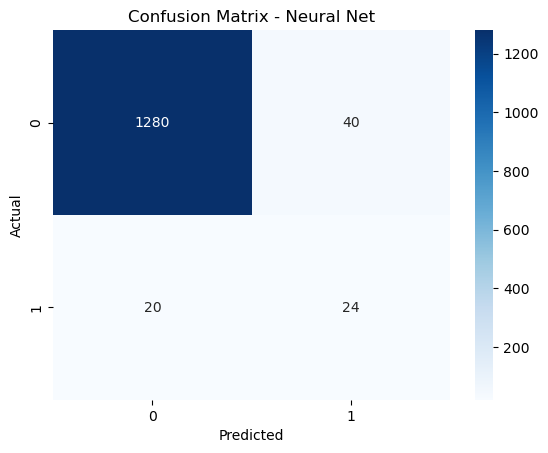

In [93]:
# Get best model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [109]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score


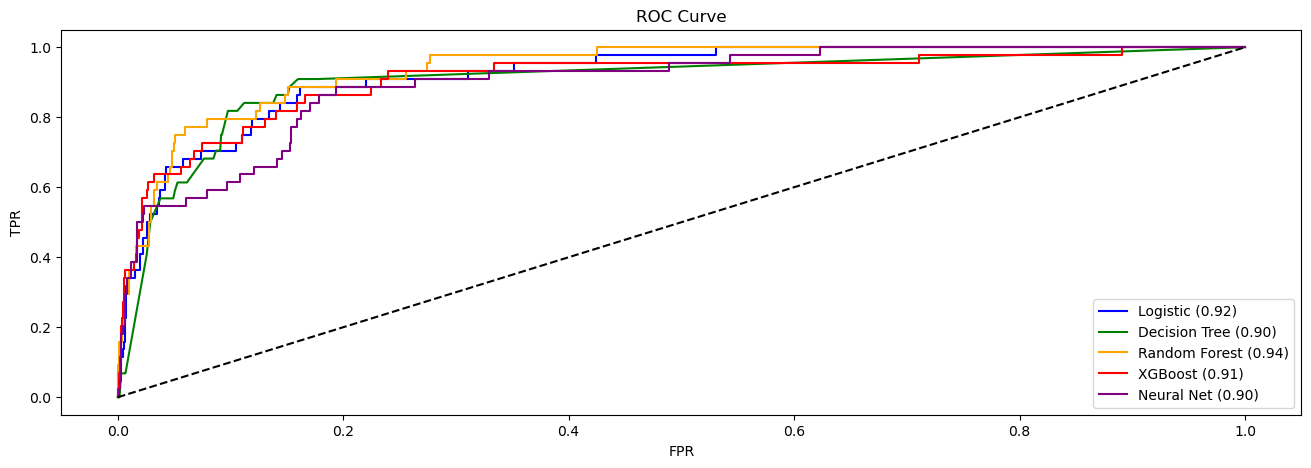

In [110]:
# --- ROC Curve ---
plt.figure(figsize=(16,5))

colors = ['blue','green','orange','red','purple']
for i, (name, model) in enumerate(models.items()):
    if not hasattr(model, "predict_proba"):
        continue
        
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, color=colors[i], label=f"{name} ({auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

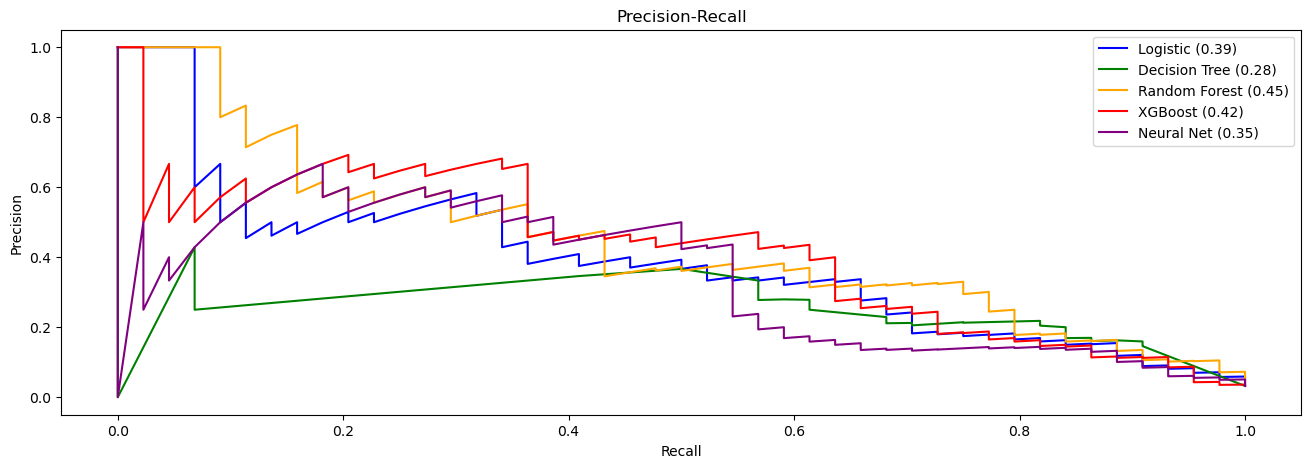

In [112]:
# --- Precision-Recall Curve ---

plt.figure(figsize=(16,5))

colors = ['blue','green','orange','red','purple']
for i, (name, model) in enumerate(models.items()):
    if not hasattr(model, "predict_proba"):
        continue
        
    y_prob = model.predict_proba(X_test)[:,1]
    p, r, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    
    plt.plot(r, p, color=colors[i], label=f"{name} ({ap:.2f})")

plt.title("Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

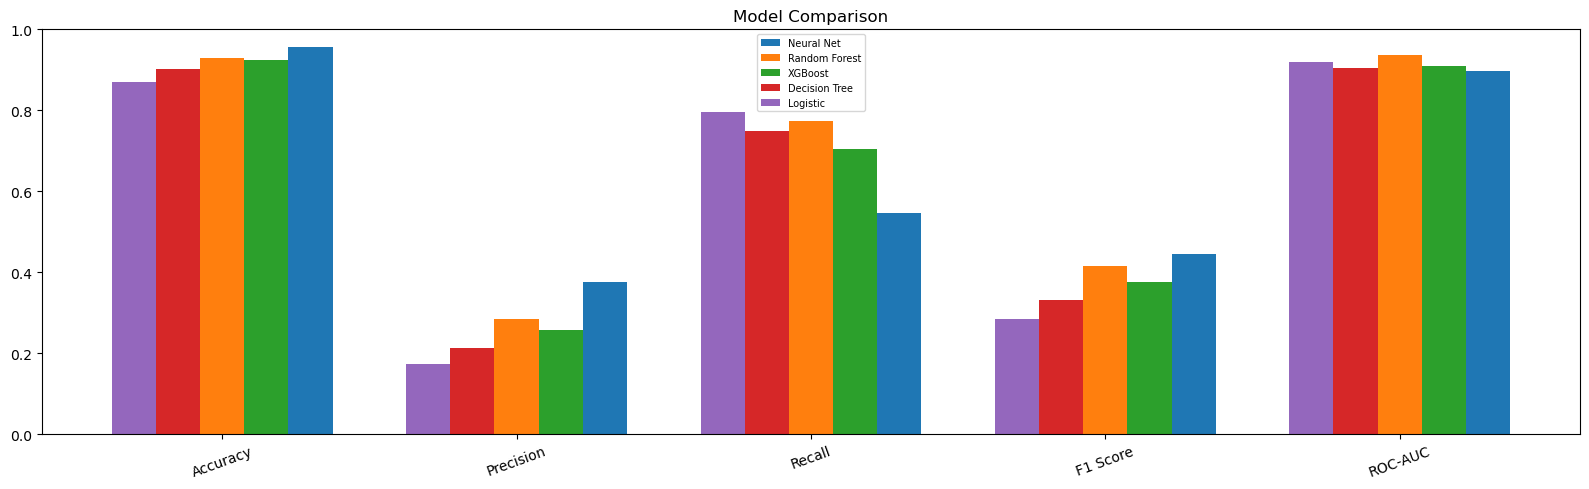

In [113]:
# --- Model Comparison Bar ---
plt.figure(figsize=(16,5))

colors = ['blue','green','orange','red','purple']
metrics = ["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
x = np.arange(len(metrics))

for i, row in results_df.iterrows():
    plt.bar(x + i*0.15, row[metrics], width=0.15, label=row["Model"])

plt.xticks(x + 0.3, metrics, rotation=20)
plt.ylim(0,1)
plt.title("Model Comparison")
plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

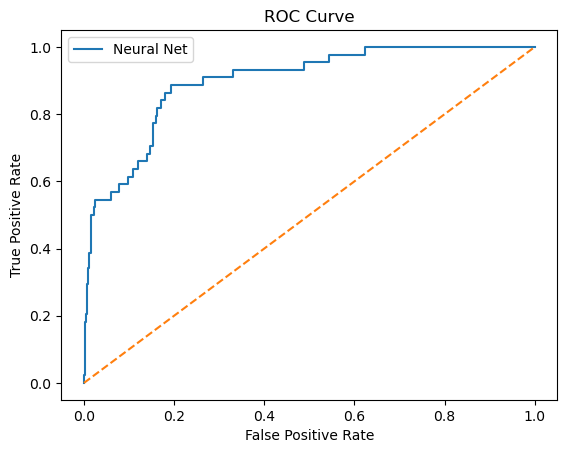

In [99]:
# ROC Curve

if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=best_model_name)
    plt.plot([0,1], [0,1], linestyle='--')
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

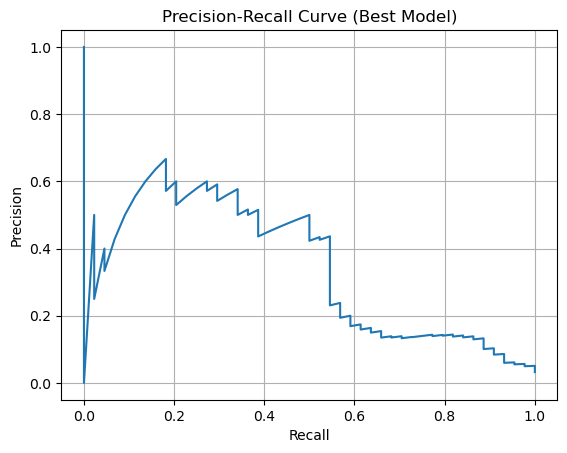

In [97]:
# Single best Model 
best_model = models[results_df.iloc[0]["Model"]]

y_scores = best_model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Best Model)")
plt.grid()
plt.show()

In [101]:
# Cross Validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic: F1 = 0.8886 ± 0.0075
Decision Tree: F1 = 0.9254 ± 0.0075
Random Forest: F1 = 0.9580 ± 0.0037
XGBoost: F1 = 0.9692 ± 0.0052
Neural Net: F1 = 0.9795 ± 0.0026


In [102]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [103]:
pipe = Pipeline([
    ('smote', SMOTE()),
    ('model', model)])

scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')

# Conclusion 